In [1]:
import os
import pickle
import sys

root_dir = os.path.abspath("..")
data_dir = os.path.join(root_dir, "data")
os.makedirs(data_dir, exist_ok=True)
if root_dir not in sys.path:
    sys.path.append(root_dir)

from current_setpoints.models.machines import ieee_machine2_trained_neural_flux
from current_setpoints.models.forward_model import ForwardModel, Fault
from current_setpoints.optimization.dynamic_optimizer import IndependentOptimizer
from current_setpoints.optimization.grid import calculate_grid
from current_setpoints.optimization.data import grid_to_data
from current_setpoints.utils.plotting import plot_grid_segments

In [2]:
CURR_MAX = 30.0
VOLT_MAX = 13.0
OMEGA_MAX = 1800.0  # mechanical RPM

SLSQP_OPTS = {"disp": False, "ftol": 1e-8, "maxiter": 500}
N_GRID = 60  # multiple of 5 -- avoids the phase-aliasing artifact confirmed in FAULT_TOLERANT.md

GRID_OPTS = {"n_torq": 15, "n_omega": 15, "torq_min": 0.0, "omega_min": 0.0}

SCENARIOS = {
    "healthy": (),
    "one_fault": (0,),
    "two_adjacent": (0, 1),
    "two_nonadjacent": (0, 2),
}

In [3]:
grids = {}
for name, open_phases in SCENARIOS.items():
    pkl_path = os.path.join(data_dir, f"fault_map_{name}.pkl")

    if os.path.isfile(pkl_path):
        with open(pkl_path, "rb") as f:
            grids[name] = pickle.load(f)
        continue

    drive = ieee_machine2_trained_neural_flux(curr_max=CURR_MAX, volt_max=VOLT_MAX, omega_max=OMEGA_MAX)
    fwd = ForwardModel(drive, n_theta=700, fault=Fault(open_phases))
    optimizer = IndependentOptimizer(fwd, opts=SLSQP_OPTS, n_grid=N_GRID)

    grid = calculate_grid(optimizer=optimizer, fwd=fwd, opts=GRID_OPTS, mode="standard")
    with open(pkl_path, "wb") as f:
        pickle.dump(grid, f)
    grids[name] = grid

Starting standard grid: 15 torques × 15 speeds
  Speed 1/15: 0.0 RPM
  Speed 2/15: 128.6 RPM
  Speed 3/15: 257.1 RPM
  Speed 4/15: 385.7 RPM
  Speed 5/15: 514.3 RPM
  Speed 6/15: 642.9 RPM
  Speed 7/15: 771.4 RPM
  Speed 8/15: 900.0 RPM
  Speed 9/15: 1028.6 RPM
  Speed 10/15: 1157.1 RPM
  Speed 11/15: 1285.7 RPM
  Speed 12/15: 1414.3 RPM
  Speed 13/15: 1542.9 RPM
  Speed 14/15: 1671.4 RPM
  Speed 15/15: 1800.0 RPM
Standard grid complete.
Starting standard grid: 15 torques × 15 speeds
  Speed 1/15: 0.0 RPM
  Speed 2/15: 128.6 RPM
  Speed 3/15: 257.1 RPM
  Speed 4/15: 385.7 RPM
  Speed 5/15: 514.3 RPM
  Speed 6/15: 642.9 RPM
  Speed 7/15: 771.4 RPM
  Speed 8/15: 900.0 RPM
  Speed 9/15: 1028.6 RPM
  Speed 10/15: 1157.1 RPM
  Speed 11/15: 1285.7 RPM
  Speed 12/15: 1414.3 RPM
  Speed 13/15: 1542.9 RPM
  Speed 14/15: 1671.4 RPM
  Speed 15/15: 1800.0 RPM
Standard grid complete.
Starting standard grid: 15 torques × 15 speeds
  Speed 1/15: 0.0 RPM
  Speed 2/15: 128.6 RPM
  Speed 3/15: 257.1 RPM

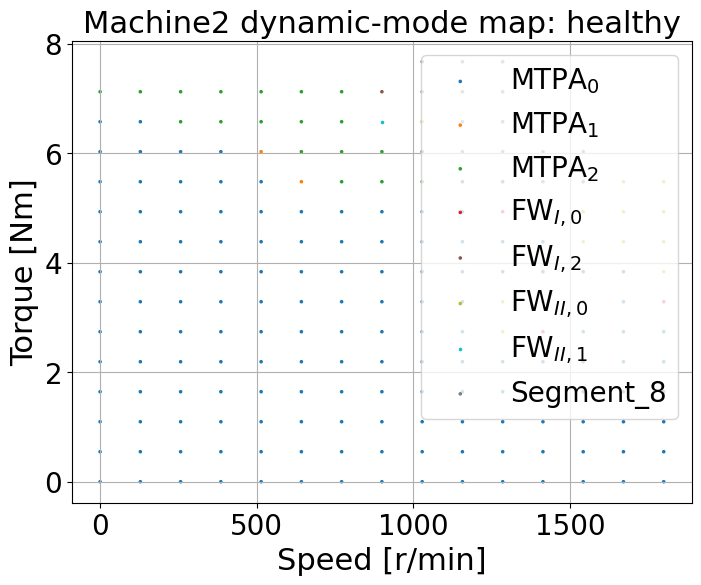

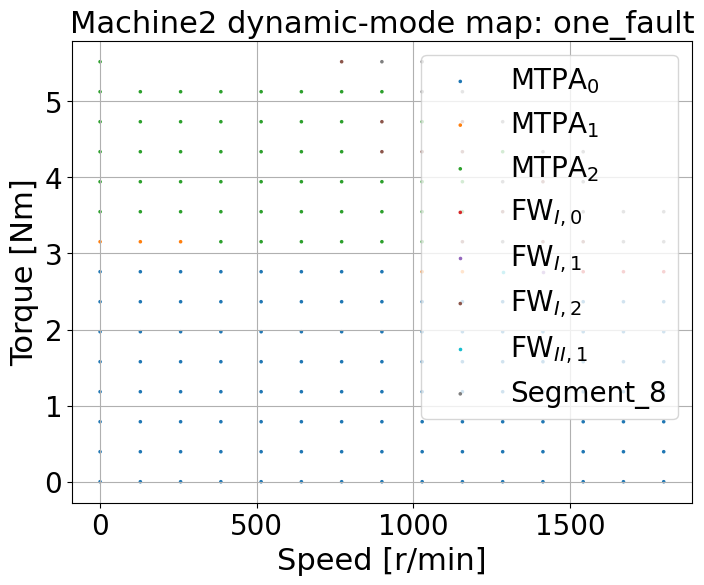

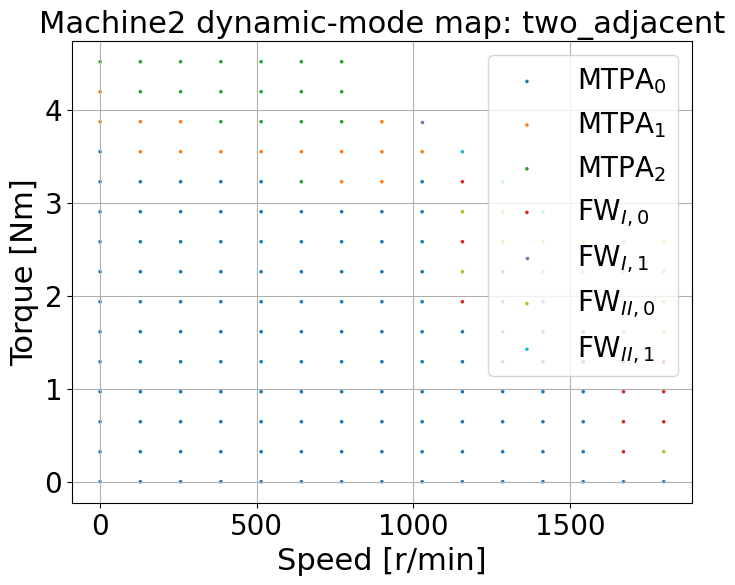

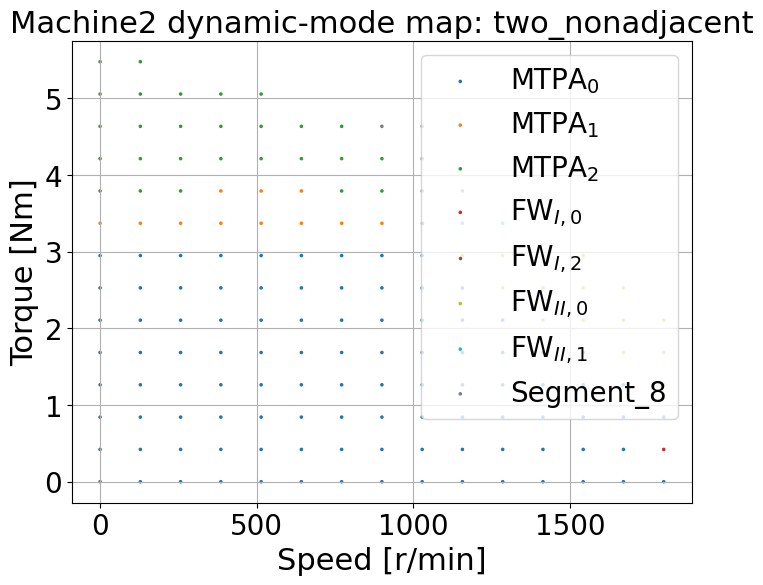

In [4]:
for name, grid in grids.items():
    data = grid_to_data(grid, k_skip=1)
    plot_grid_segments(data, title=f"Machine2 dynamic-mode map: {name}")

In [5]:
class FirstHarmonicOnlyOptimizer(IndependentOptimizer):
    # Fall (2016)-style restriction: only (id1, iq1) are free/optimized;
    # (id3, iq3) are forced to zero rather than left as a free dimension. Same
    # fault handling, current/voltage limits, and per-angle solve engine as
    # IndependentOptimizer -- only the extra equality constraint differs.

    def _per_angle_constraints(self, maps, omega, n, torq_target):
        cons = super()._per_angle_constraints(maps, omega, n, torq_target)
        cons.append({"type": "eq", "fun": lambda x: x[2]})
        cons.append({"type": "eq", "fun": lambda x: x[3]})
        return cons


grids_first_harmonic = {}
for name, open_phases in SCENARIOS.items():
    pkl_path = os.path.join(data_dir, f"fault_map_first_harmonic_{name}.pkl")

    if os.path.isfile(pkl_path):
        with open(pkl_path, "rb") as f:
            grids_first_harmonic[name] = pickle.load(f)
        continue

    drive = ieee_machine2_trained_neural_flux(curr_max=CURR_MAX, volt_max=VOLT_MAX, omega_max=OMEGA_MAX)
    fwd = ForwardModel(drive, n_theta=700, fault=Fault(open_phases))
    optimizer = FirstHarmonicOnlyOptimizer(fwd, opts=SLSQP_OPTS, n_grid=N_GRID)

    grid = calculate_grid(optimizer=optimizer, fwd=fwd, opts=GRID_OPTS, mode="standard")
    with open(pkl_path, "wb") as f:
        pickle.dump(grid, f)
    grids_first_harmonic[name] = grid

Starting standard grid: 15 torques × 15 speeds
  Speed 1/15: 0.0 RPM
  Speed 2/15: 128.6 RPM
  Speed 3/15: 257.1 RPM
  Speed 4/15: 385.7 RPM
  Speed 5/15: 514.3 RPM
  Speed 6/15: 642.9 RPM
  Speed 7/15: 771.4 RPM
  Speed 8/15: 900.0 RPM
  Speed 9/15: 1028.6 RPM
  Speed 10/15: 1157.1 RPM
  Speed 11/15: 1285.7 RPM
  Speed 12/15: 1414.3 RPM
  Speed 13/15: 1542.9 RPM
  Speed 14/15: 1671.4 RPM
  Speed 15/15: 1800.0 RPM
Standard grid complete.
Starting standard grid: 15 torques × 15 speeds
  Speed 1/15: 0.0 RPM
  Speed 2/15: 128.6 RPM
  Speed 3/15: 257.1 RPM
  Speed 4/15: 385.7 RPM
  Speed 5/15: 514.3 RPM
  Speed 6/15: 642.9 RPM
  Speed 7/15: 771.4 RPM
  Speed 8/15: 900.0 RPM
  Speed 9/15: 1028.6 RPM
  Speed 10/15: 1157.1 RPM
  Speed 11/15: 1285.7 RPM
  Speed 12/15: 1414.3 RPM
  Speed 13/15: 1542.9 RPM
  Speed 14/15: 1671.4 RPM
  Speed 15/15: 1800.0 RPM
Standard grid complete.
Starting standard grid: 15 torques × 15 speeds
  Speed 1/15: 0.0 RPM
  Speed 2/15: 128.6 RPM
  Speed 3/15: 257.1 RPM

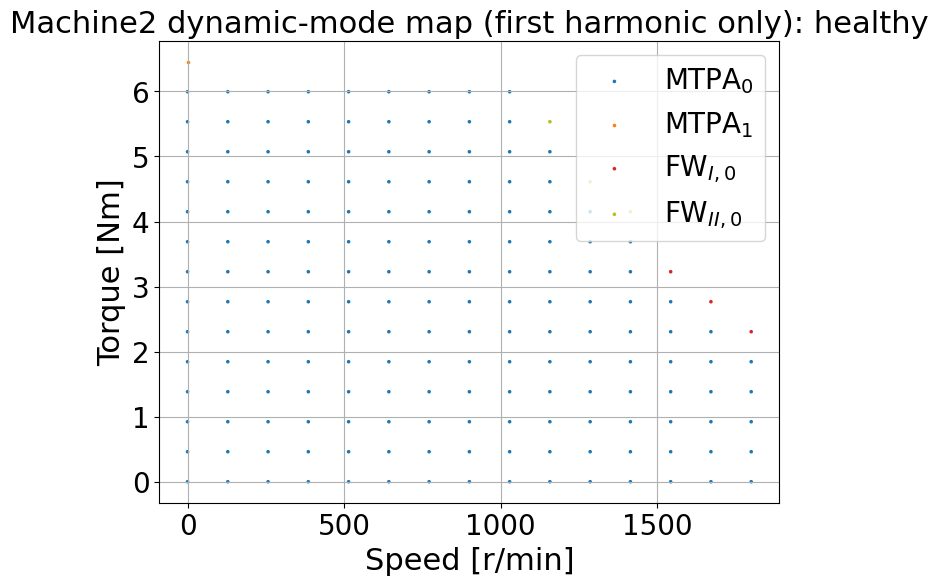

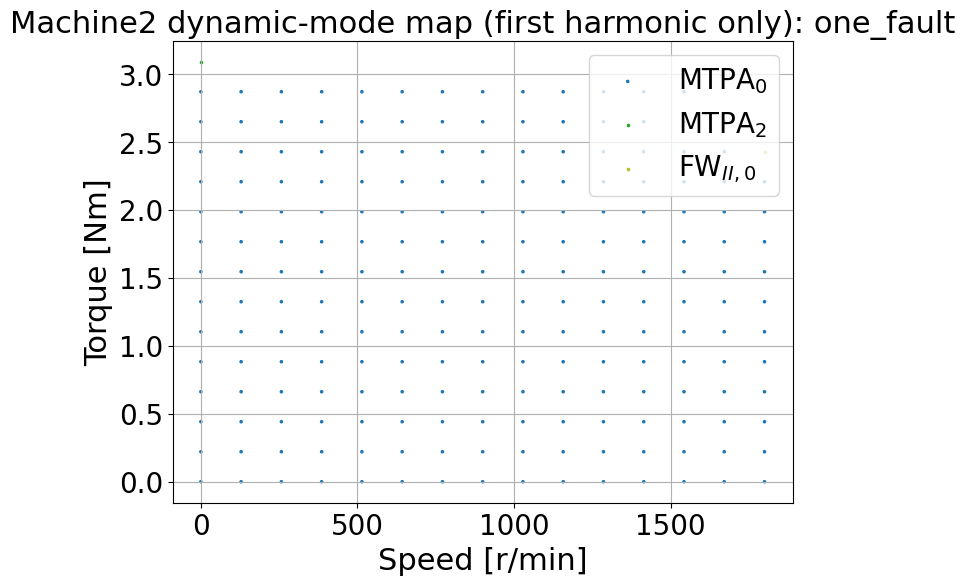

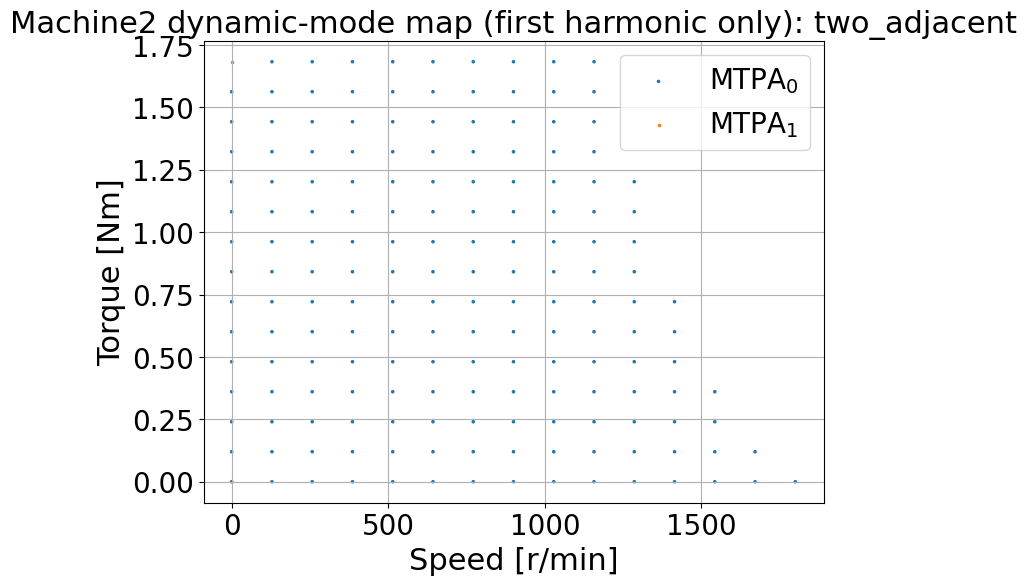

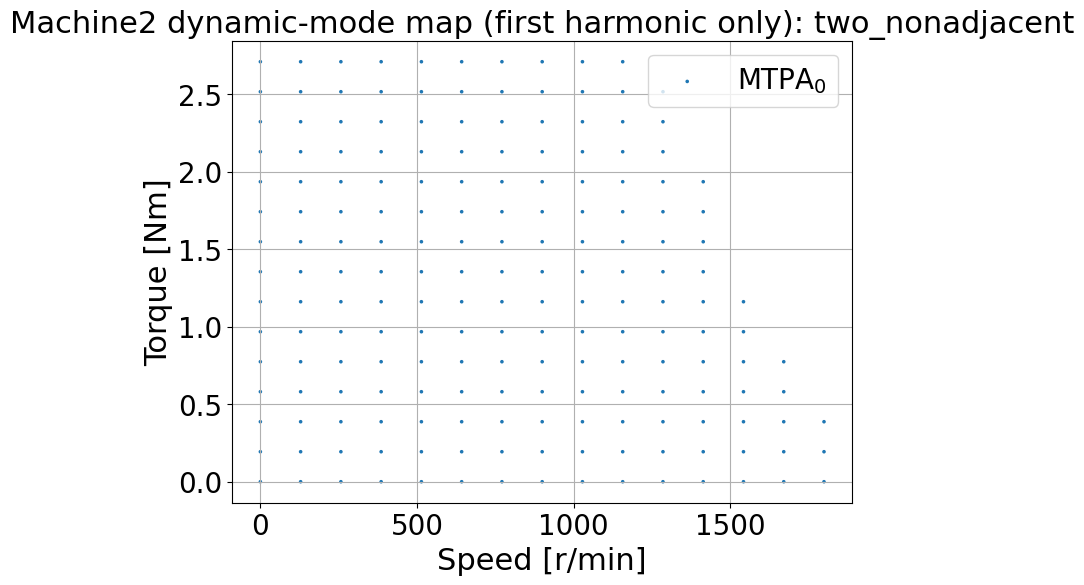

In [6]:
for name, grid in grids_first_harmonic.items():
    data = grid_to_data(grid, k_skip=1)
    plot_grid_segments(data, title=f"Machine2 dynamic-mode map (first harmonic only): {name}")